In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# read all words

words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
len(words)

32033

In [ ]:
# build the vocabulary and mapping to/from intergers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset

block_size = 3 # context window length
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X) # This is the context data. For example . . . (0, 0 ,0)
Y = torch.tensor(Y) # This is the actual output of the data. In the example above (0,0,0) will follow with a number for example (5)



In [ ]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
C = torch.randn((27, 10))
C

tensor([[-0.2902,  2.3930,  0.1746,  0.8595,  0.9980, -0.2724, -0.6682, -1.1341,
          0.4097,  0.1243],
        [ 0.2339,  0.2654,  1.5413,  0.5973, -0.6670,  0.6237, -0.1518, -1.1094,
          0.5378, -0.1062],
        [ 0.4319,  0.6412, -0.1340, -0.6956, -0.1179,  0.7829, -0.3123, -0.5049,
         -0.3933, -0.7078],
        [ 0.7831,  0.5016, -0.2080, -0.0817,  0.2720,  2.6974,  1.1085, -0.7225,
          0.4718,  1.4908],
        [-0.6311, -0.4035, -0.9474, -0.4849,  0.7681, -0.5936, -0.6590, -0.4852,
          1.1121,  0.4114],
        [ 0.0299, -1.2253, -0.9126, -0.9785, -0.7248,  0.1862,  0.8201,  0.7576,
         -0.1044,  0.0648],
        [ 0.7384,  0.3554,  1.1777,  0.4140, -0.7843, -0.1706, -0.3645,  0.9956,
         -0.2413, -0.7897],
        [-0.6751,  0.1933,  1.7886,  0.4269,  1.0258,  0.7248,  1.0711, -1.9943,
         -2.4807,  0.0688],
        [-1.5193, -0.3430, -0.3993,  0.0081,  0.1405, -0.1408, -0.7833, -0.8928,
         -1.4662,  0.1171],
        [-0.8364, -

In [9]:
C[5] # This is the easy approach

# # This is a harder approach that karpathy do not use in this example.
# F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.0299, -1.2253, -0.9126, -0.9785, -0.7248,  0.1862,  0.8201,  0.7576,
        -0.1044,  0.0648])

In [10]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 10])

In [11]:
W1 = torch.randn((6, 100)) 
b1 = torch.randn(100)
print(emb.view(-1, 30).shape) # this concatenates the vectors in the snd and thrd dimension. So we can multiply it  with W1
emb.view(-1 ,30)[0] # This is how it looks a full zero of '.' array.


torch.Size([228146, 30])


tensor([-0.2902,  2.3930,  0.1746,  0.8595,  0.9980, -0.2724, -0.6682, -1.1341,
         0.4097,  0.1243, -0.2902,  2.3930,  0.1746,  0.8595,  0.9980, -0.2724,
        -0.6682, -1.1341,  0.4097,  0.1243, -0.2902,  2.3930,  0.1746,  0.8595,
         0.9980, -0.2724, -0.6682, -1.1341,  0.4097,  0.1243])

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 

In [ ]:
h

tensor([[ 0.9360,  0.9953, -1.0000,  ...,  0.0037, -0.9999, -0.9271],
        [-0.6039,  1.0000,  0.8969,  ...,  0.9533, -0.9969,  0.9999],
        [-0.3548, -0.9961, -0.9552,  ..., -0.7175,  0.9221,  0.0465],
        ...,
        [-0.9957,  0.6304, -0.9999,  ...,  0.0612,  0.0653, -0.8856],
        [-0.6807,  1.0000,  0.4834,  ..., -0.6706, -0.9999,  1.0000],
        [ 1.0000,  0.9301, -0.9984,  ..., -0.1390, -0.9565,  0.9346]])

In [ ]:
h.shape

torch.Size([1140730, 100])

In [ ]:
W2 = torch.randn(100, 27)
b2 = torch.randn(27)

In [ ]:
logits = h @ W2 + b2

In [ ]:
logits.shape

torch.Size([1140730, 27])

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts / counts.sum(1, keepdim=True)

In [ ]:
prob.shape

torch.Size([1140730, 27])

In [ ]:
# ------- Training proccess ---------------


In [142]:
def build_dataset(words):
    block_size = 5 # context window length
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)   
            context = context[1:] + [ix]

    X = torch.tensor(X) 
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Y_te = build_dataset(words[n2:])

torch.Size([182400, 5]) torch.Size([182400])
torch.Size([22962, 5]) torch.Size([22962])
torch.Size([22784, 5]) torch.Size([22784])


In [143]:
Xtr.shape, Ytr.shape

(torch.Size([182400, 5]), torch.Size([182400]))

In [144]:
# Initializing values randomely 
n_embd = 10    
n_hidden = 200
block_size = 5

input_nodes = block_size * n_embd

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, n_embd), generator=g) # embedding function
W1 = torch.randn((input_nodes, n_hidden), generator=g) * (5/3 / input_nodes**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.zeros(27)
parameters = [C, W1, b1, W2, b2]

In [145]:
sum(p.nelement() for p in parameters)

15897

In [146]:
for p in parameters:
    p.requires_grad = True

In [147]:
lre = torch.linspace(-3 , 0, 30000)
lrs = 10**lre

In [148]:
lri = []
lossi = []
stepi = []

In [ ]:
for i in range(200000):

    # selection of random minibatches
    ix = torch.randint(0, Xtr.shape[0], (64,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, input_nodes) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True) 
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    if i < 100000:
        lr = 0.1
    elif i < 150000:
        lr = 0.01  # Nivel intermedio
    else:
        lr = 0.005  # Pulido final

    for p in parameters:
        p.data += -lr * p.grad

    # track metrics
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    
# print(loss.item())

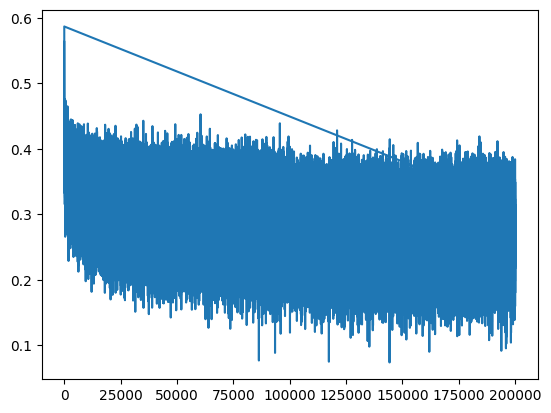

In [139]:
plt.plot(stepi, lossi)

In [140]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, input_nodes) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

1.907198190689087

In [141]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, input_nodes) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.0558955669403076